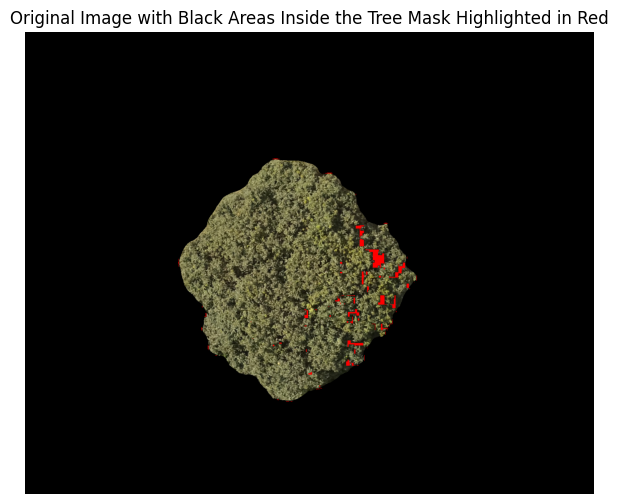

Tree mask area: 299524 pixels
Red area inside tree mask: 5286 pixels
Percentage of red area inside tree mask: 1.76%


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

image_path = 'DJI_5040_mask_2.png' 
image = imread(image_path)

image_height, image_width, _ = image.shape
total_image_area = image_height * image_width

gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Use Canny edge detector to find edges in the image
edges = cv2.Canny(blurred_image, 50, 150)

kernel = np.ones((5, 5), np.uint8)
dilated = cv2.dilate(edges, kernel, iterations=1)

contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Assume the largest contour is the tree
if contours:
    largest_contour = max(contours, key=cv2.contourArea)

    
    tree_mask = np.zeros_like(gray_image)
    cv2.drawContours(tree_mask, [largest_contour], -1, (255), thickness=cv2.FILLED)
    tree_only = cv2.bitwise_and(image, image, mask=tree_mask)

    gray_image_tree_only = cv2.cvtColor(tree_only, cv2.COLOR_RGB2GRAY)
    blurred_tree_only = cv2.GaussianBlur(gray_image_tree_only, (5, 5), 0)
    edges_tree_only = cv2.Canny(blurred_tree_only, 50, 150)

    contours_tree_only, _ = cv2.findContours(edges_tree_only, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask_tree_only = np.zeros_like(gray_image_tree_only)


    for contour in contours_tree_only:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(mask_tree_only, (x, y), (x + w, y + h), (255), -1)  

    inverted_mask_tree_only = 255 - mask_tree_only
    image_with_red_areas = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    # Coloring the black areas inside the tree mask in red
    image_with_red_areas[(mask_tree_only == 0) & (tree_mask == 255)] = [0, 0, 255]  

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(image_with_red_areas, cv2.COLOR_BGR2RGB))
    plt.title('Original Image with Black Areas Inside the Tree Mask Highlighted in Red')
    plt.axis('off')
    plt.show()

    # Calculate the area of the red regions inside the tree mask
    red_area_inside_tree = np.sum((mask_tree_only == 0) & (tree_mask == 255))

    # Calculate the total tree area
    tree_area = np.sum(tree_mask == 255)

    print(f"Tree mask area: {tree_area} pixels")
    print(f"Red area inside tree mask: {red_area_inside_tree} pixels")
    print(f"Percentage of red area inside tree mask: {(red_area_inside_tree / tree_area) * 100:.2f}%")

else:
    print("No contours found capable of isolating the tree.")

